# MIMIC basic usage

Fit MIMIC on a mixed tabular dataset, impute missing values, inspect confidence, and plot the original/preprocessed space against the learned embedding.

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mimic import MIMIC

rng = np.random.default_rng(0)
n = 120
age = rng.normal(50, 12, n)
income = 20000 + age * 850 + rng.normal(0, 5000, n)
segment = np.where(age > 50, "older", "younger")
outcome = np.where(income > np.median(income), "yes", "no")
df = pd.DataFrame({"id": range(n), "age": age, "income": income, "segment": segment, "outcome": outcome})
df.loc[rng.choice(n, 10, replace=False), "age"] = np.nan
df.loc[rng.choice(n, 8, replace=False), "outcome"] = np.nan
df.head()

,id,age,income,segment,outcome
0,0,51.508763,67720.389364,older,NaN
1,1,48.414742,65372.923797,younger,NaN
2,2,57.685072,69410.279088,older,yes
3,3,51.258801,56436.111940,older,no
4,4,43.571968,56360.946894,younger,no


In [2]:
mimic = MIMIC(
    columns={
        "ignore": ["id"],
        "regression": ["age", "income"],
        "classification": ["segment", "outcome"],
    },
    mode="direct",# modes: "identity", "direct", "factorised", "joint"
    capacity=0.25,
    random_state=0,
)
mimic.fit(df)
embedding = mimic.transform(df)
embedding.shape

(120, 132)

In [3]:
imputed, confidence = mimic.impute(df, return_confidence=True)
imputed.head(), confidence.head()

(   id        age        income  segment outcome
 0   0  51.508763  67720.389364    older     yes
 1   1  48.414742  65372.923797  younger     yes
 2   2  57.685072  69410.279088    older     yes
 3   3  51.258801  56436.111940    older      no
 4   4  43.571968  56360.946894  younger      no,
    row_index column        task prediction   observed      bias  variance  \
 0          0    age  regression  60.782482  51.508763  0.431919  0.276135   
 1          1    age  regression  45.606097  48.414742  0.431919  1.814052   
 2          2    age  regression  61.208926  57.685072  0.431919  0.708212   
 3          3    age  regression  51.129891  51.258801  0.431919  2.215819   
 4          4    age  regression  41.425102  43.571968  0.431919  0.811440   
 
    residual  uncertainty  discrepancy  ...  probability_std  probability_min  \
 0 -9.273719    28.976310     9.273719  ...              NaN              NaN   
 1  2.808645    30.514227     2.808645  ...              NaN             

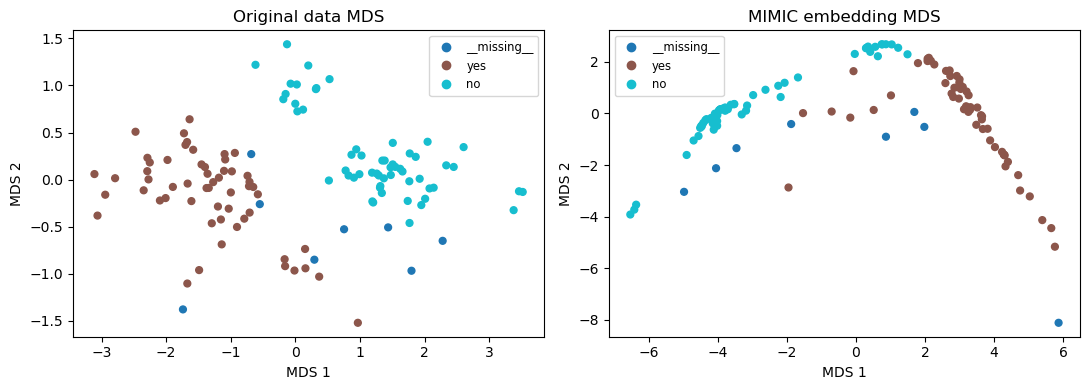

In [4]:
fig, axes = mimic.plot(df, color_by="outcome", center="random", random_state=0)